Transformer (Built from Scratch) — Sequence Classification

In [3]:
# CELL 1 — Imports
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
# CELL 2 — Load dataset (AG News — same task type as GLU notebook, so you can compare architectures)
from datasets import load_dataset

ds = load_dataset("wangrongsheng/ag_news")
train_data = ds["train"]
test_data = ds["test"]
class_names = ["World", "Sports", "Business", "Sci/Tech"]

print(f"Train samples: {len(train_data)} | Test samples: {len(test_data)}")

Train samples: 120000 | Test samples: 7600


In [5]:
# CELL 3 — Build vocabulary and encode text
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9' ]", " ", text)
    return text.split()

MAX_VOCAB_SIZE = 15000
counter = Counter()
subset_for_vocab = train_data.shuffle(seed=42).select(range(10000))
for item in subset_for_vocab:
    counter.update(tokenize(item["text"]))

most_common = counter.most_common(MAX_VOCAB_SIZE - 2)
vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in most_common:
    vocab[word] = len(vocab)

MAX_LEN = 60

def encode(text, vocab, max_len=MAX_LEN):
    tokens = tokenize(text)
    ids = [vocab.get(tok, vocab["<unk>"]) for tok in tokens[:max_len]]
    if len(ids) < max_len:
        ids += [vocab["<pad>"]] * (max_len - len(ids))
    return ids

print(f"Vocab size: {len(vocab)}")

Vocab size: 15000


In [6]:
# CELL 4 — Dataset and DataLoaders
class AGNewsDataset(Dataset):
    def __init__(self, hf_data, vocab, max_len=MAX_LEN):
        self.data = hf_data
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        ids = encode(item["text"], self.vocab, self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(item["label"], dtype=torch.long)

train_subset = train_data.shuffle(seed=42).select(range(20000))
test_subset = test_data.shuffle(seed=42).select(range(3000))

train_dataset = AGNewsDataset(train_subset, vocab)
test_dataset = AGNewsDataset(test_subset, vocab)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

Train samples: 20000 | Test samples: 3000


In [7]:
# CELL 5 — Positional encoding (Transformers have no recurrence, so position must be injected manually)
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # [1, max_len, embed_dim]

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

In [8]:
# CELL 6 — Multi-head self-attention (built from scratch)
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, mask=None):
        batch_size, seq_len, embed_dim = x.shape

        # Project and split into heads: [batch, seq_len, embed_dim] -> [batch, num_heads, seq_len, head_dim]
        Q = self.q_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn_weights = torch.softmax(scores, dim=-1)  # softmax over key dimension — attention weights
        attn_output = torch.matmul(attn_weights, V)

        # Recombine heads: [batch, num_heads, seq_len, head_dim] -> [batch, seq_len, embed_dim]
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, embed_dim)
        return self.out_proj(attn_output)

In [9]:
# CELL 7 — Transformer encoder block (self-attention + GELU feedforward, with residuals & layer norm)
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        # Feedforward block uses GELU — same choice as BERT, smoother than ReLU
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Residual connection + layer norm around attention (pre-norm-ish, post-norm style used here)
        attn_out = self.attn(x, mask)
        x = self.norm1(x + self.dropout(attn_out))

        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x

In [10]:
# CELL 8 — Full model: embedding + positional encoding + stacked encoder blocks + classifier
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, ff_dim=256,
                 num_layers=3, num_classes=4, pad_idx=0, max_len=MAX_LEN):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(embed_dim, max_len=max_len)
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim) for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        mask = (x != 0).unsqueeze(1).unsqueeze(2)  # mask out <pad> tokens in attention

        embedded = self.embedding(x) * math.sqrt(self.embedding.embedding_dim)  # standard scaling
        x = self.pos_encoding(embedded)
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x, mask)

        # Use mean pooling over non-pad tokens as the sequence representation
        pad_mask = (x.new_ones(x.shape[:2]) if False else None)  # placeholder (unused)
        pooled = x.mean(dim=1)  # [batch, embed_dim]
        return self.classifier(pooled)

model = TransformerClassifier(vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

TransformerClassifier(
  (embedding): Embedding(15000, 128, padding_idx=0)
  (pos_encoding): PositionalEncoding()
  (blocks): ModuleList(
    (0-2): 3 x TransformerEncoderBlock(
      (attn): MultiHeadSelfAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=128, bias=True)
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_f

In [11]:
# CELL 9 — Training loop
epochs = 8
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for sequences, labels in train_loader:
        sequences, labels = sequences.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(sequences)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}%")

Epoch 1/8 — Loss: 0.8543 | Train Acc: 66.49%
Epoch 2/8 — Loss: 0.5547 | Train Acc: 79.92%
Epoch 3/8 — Loss: 0.4382 | Train Acc: 84.49%
Epoch 4/8 — Loss: 0.3768 | Train Acc: 86.66%
Epoch 5/8 — Loss: 0.3269 | Train Acc: 88.54%
Epoch 6/8 — Loss: 0.2905 | Train Acc: 89.67%
Epoch 7/8 — Loss: 0.2628 | Train Acc: 90.77%
Epoch 8/8 — Loss: 0.2304 | Train Acc: 92.06%


In [12]:
# CELL 9 — Training loop
epochs = 8
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for sequences, labels in train_loader:
        sequences, labels = sequences.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(sequences)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}%")

Epoch 1/8 — Loss: 0.2048 | Train Acc: 92.96%
Epoch 2/8 — Loss: 0.1881 | Train Acc: 93.42%
Epoch 3/8 — Loss: 0.1709 | Train Acc: 93.89%
Epoch 4/8 — Loss: 0.1556 | Train Acc: 94.41%
Epoch 5/8 — Loss: 0.1442 | Train Acc: 94.81%
Epoch 6/8 — Loss: 0.1347 | Train Acc: 95.27%
Epoch 7/8 — Loss: 0.1249 | Train Acc: 95.59%
Epoch 8/8 — Loss: 0.1146 | Train Acc: 95.89%


In [13]:
# CELL 10 — Evaluation
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for sequences, labels in test_loader:
        sequences, labels = sequences.to(device), labels.to(device)
        logits = model(sequences)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 88.00%


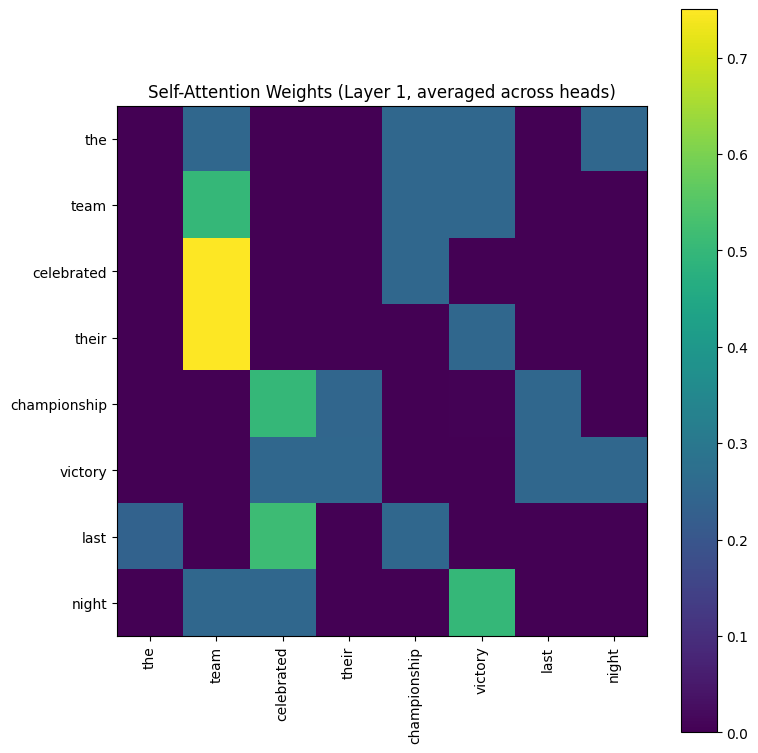

In [14]:
# CELL 11 — Visualize attention weights (see what the model "looks at")
def get_attention_weights(model, text, vocab, layer_idx=0):
    model.eval()
    tokens = tokenize(text)[:MAX_LEN]
    ids = encode(text, vocab)
    tensor = torch.tensor([ids], dtype=torch.long).to(device)

    # Hook into the target layer's attention module to capture weights
    captured = {}
    def hook(module, input, output):
        pass  # placeholder; we recompute weights manually below for clarity

    with torch.no_grad():
        mask = (tensor != 0).unsqueeze(1).unsqueeze(2)
        embedded = model.embedding(tensor) * math.sqrt(model.embedding.embedding_dim)
        x = model.pos_encoding(embedded)

        for i, block in enumerate(model.blocks):
            attn_layer = block.attn
            Q = attn_layer.q_proj(x).view(1, -1, attn_layer.num_heads, attn_layer.head_dim).transpose(1, 2)
            K = attn_layer.k_proj(x).view(1, -1, attn_layer.num_heads, attn_layer.head_dim).transpose(1, 2)
            scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(attn_layer.head_dim)
            weights = torch.softmax(scores, dim=-1)
            if i == layer_idx:
                return weights[0].mean(dim=0).cpu().numpy(), tokens  # average across heads
            x = block(x, mask)

get_attention_weights_result, tokens = get_attention_weights(
    model, "The team celebrated their championship victory last night.", vocab, layer_idx=0
)

import matplotlib.pyplot as plt
n = len(tokens)
plt.figure(figsize=(8, 8))
plt.imshow(get_attention_weights_result[:n, :n], cmap="viridis")
plt.xticks(range(n), tokens, rotation=90)
plt.yticks(range(n), tokens)
plt.title("Self-Attention Weights (Layer 1, averaged across heads)")
plt.colorbar()
plt.tight_layout()
plt.show()

In [15]:
# CELL 12 — Try it on custom headlines
def predict_topic(text, model, vocab):
    model.eval()
    ids = encode(text, vocab)
    tensor = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
    return class_names[pred], probs[0][pred].item()

sample_headlines = [
    "The central bank raised interest rates by half a point today.",
    "The striker scored a hat-trick in the final minutes of the match.",
    "Scientists discover a new exoplanet orbiting a distant star.",
    "Tensions rise as diplomats meet for emergency peace talks."
]

for headline in sample_headlines:
    topic, conf = predict_topic(headline, model, vocab)
    print(f"Headline: {headline}\nPredicted topic: {topic} (confidence: {conf:.2f})\n")

Headline: The central bank raised interest rates by half a point today.
Predicted topic: Business (confidence: 0.99)

Headline: The striker scored a hat-trick in the final minutes of the match.
Predicted topic: Sports (confidence: 1.00)

Headline: Scientists discover a new exoplanet orbiting a distant star.
Predicted topic: Sci/Tech (confidence: 1.00)

Headline: Tensions rise as diplomats meet for emergency peace talks.
Predicted topic: World (confidence: 1.00)

